In [3]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.offline import init_notebook_mode
init_notebook_mode(connected=True)
from plotly.subplots import make_subplots

from sklearn.preprocessing import MinMaxScaler

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("imtkaggleteam/crypto-xrpusdt")

print("Path to dataset files:", path)

Path to dataset files: /root/.cache/kagglehub/datasets/imtkaggleteam/crypto-xrpusdt/versions/4


In [36]:
df=pd.read_csv(path+'/XRPUSDT20182024new.csv')
df

,Date,Price,Open,High,Low,Vol,Change %
0,5/26/2024,0.5341,0.5416,0.5418,0.5328,178450000.0,-1.39%
1,5/25/2024,0.5416,0.5359,0.5425,0.5334,246380000.0,1.09%
2,5/24/2024,0.5358,0.5288,0.5372,0.5169,513880000.0,1.33%
3,5/23/2024,0.5288,0.5269,0.5456,0.5091,948100000.0,0.38%
4,5/22/2024,0.5268,0.5372,0.5382,0.5236,509460000.0,-1.94%
...,...,...,...,...,...,...,...
2187,5/30/2018,0.5938,0.5994,0.6255,0.5786,132830000.0,-0.93%
2188,5/29/2018,0.5994,0.5476,0.6088,0.5444,155950000.0,9.45%
2189,5/28/2018,0.5476,0.6047,0.6075,0.5460,158340000.0,-9.43%
2190,5/27/2018,0.6046,0.6088,0.6119,0.5988,95150000.0,-0.68%


In [37]:
df = pd.DataFrame(df)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2192 entries, 0 to 2191
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Date      2192 non-null   object 
 1   Price     2192 non-null   float64
 2   Open      2192 non-null   float64
 3   High      2192 non-null   float64
 4   Low       2192 non-null   float64
 5   Vol       2192 non-null   float64
 6   Change %  2192 non-null   object 
dtypes: float64(5), object(2)
memory usage: 120.0+ KB


In [38]:
df.drop(['Change %'], axis=1, inplace=True)

In [39]:
df = df.iloc[::-1]
df.reset_index(inplace=True)

In [40]:
df.drop(['index'], axis=1, inplace=True)

In [41]:
df.rename(columns = {'Vol':'Volume'}, inplace = True)
df.rename(columns = {'Price':'Close'}, inplace = True)

In [42]:
print(df.duplicated().sum())

0


In [43]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

In [44]:
df['Volume'] = df['Volume'].astype('float64')

In [45]:
# prompt: candle stick plot

fig = go.Figure(data=[go.Candlestick(x=df['Date'],
                open=df['Open'],
                high=df['High'],
                low=df['Low'],
                close=df['Close'])])

fig.show()


In [46]:
fig = make_subplots(rows=2, cols=1, shared_xaxes=True,
               vertical_spacing=0.03, subplot_titles=('Ripple', 'Volume'),
               row_width=[0.2, 0.7])

fig.add_trace(go.Candlestick(x=df["Date"], open=df["Open"], high=df["High"],
                low=df["Low"], close=df["Close"], name="Ripple"),
                row=1, col=1
)

fig.update_layout(
    yaxis_title='XRPUSDT',
    shapes = [dict(
        x0='2018-05-22', x1='2024-05-22', y0=0, y1=1, xref='x', yref='paper',
        line_width=2)],
)

fig.add_trace(go.Bar(x=df['Date'], y=df['Volume'], showlegend=False), row=2, col=1)

fig.update_layout(xaxis_rangeslider_visible=False)
fig.update(layout_xaxis_rangeslider_visible=False)

fig.show()

In [32]:
pip install mplfinance

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 3.9 MB/s eta 0:00:00


In [51]:
df2=df.copy()

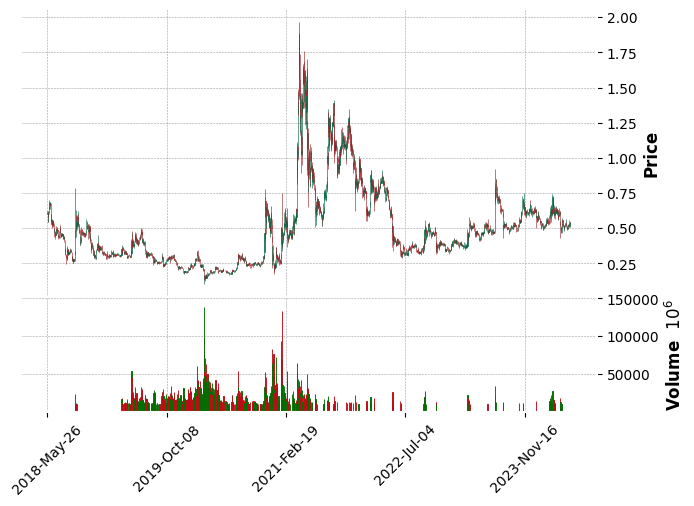

In [54]:
# prompt: candle stick plot with plotly

import mplfinance as mpf

mpf.plot(df2, type='candle', volume=True, style='charles')


In [55]:
df["5d_sma"] = df["Close"].rolling(5).mean()
df["9d_sma"] = df["Close"].rolling(9).mean()
df["17d_sma"] = df["Close"].rolling(17).mean()

In [56]:
df['5d_sma'] = df['5d_sma'].fillna(df['Close'])
df['9d_sma'] = df['9d_sma'].fillna(df['Close'])
df['17d_sma'] = df['17d_sma'].fillna(df['Close'])

In [57]:
df

,Date,Close,Open,High,Low,Volume,5d_sma,9d_sma,17d_sma
0,2018-05-26,0.6088,0.6056,0.6247,0.5989,99110000.0,0.60880,0.608800,0.608800
1,2018-05-27,0.6046,0.6088,0.6119,0.5988,95150000.0,0.60460,0.604600,0.604600
2,2018-05-28,0.5476,0.6047,0.6075,0.5460,158340000.0,0.54760,0.547600,0.547600
3,2018-05-29,0.5994,0.5476,0.6088,0.5444,155950000.0,0.59940,0.599400,0.599400
4,2018-05-30,0.5938,0.5994,0.6255,0.5786,132830000.0,0.59084,0.593800,0.593800
...,...,...,...,...,...,...,...,...,...
2187,2024-05-22,0.5268,0.5372,0.5382,0.5236,509460000.0,0.52652,0.521178,0.517988
2188,2024-05-23,0.5288,0.5269,0.5456,0.5091,948100000.0,0.52804,0.524378,0.517329
2189,2024-05-24,0.5358,0.5288,0.5372,0.5169,513880000.0,0.53326,0.526244,0.517982
2190,2024-05-25,0.5416,0.5359,0.5425,0.5334,246380000.0,0.53404,0.529133,0.519429


In [59]:
df2=df.copy()

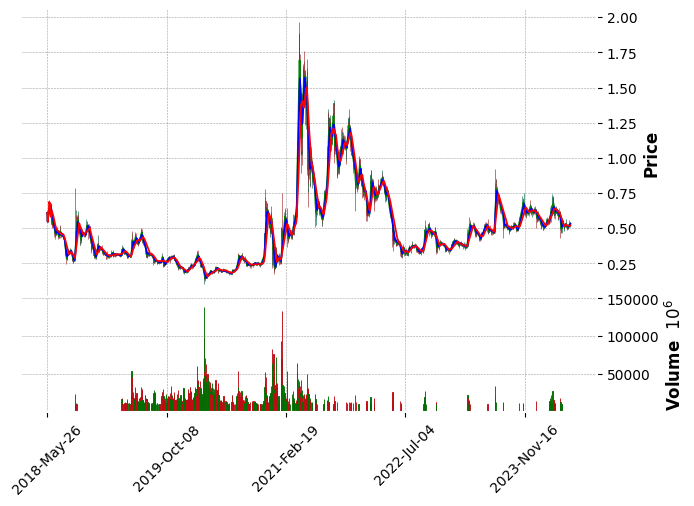

In [67]:
# prompt: candlestick plot

import mplfinance as mpf

# Assuming 'df2' is already defined and contains the necessary data
# with columns 'Date', 'Open', 'High', 'Low', 'Close', 'Volume'
# and the calculated SMAs (5d_sma, 9d_sma, 17d_sma)
df2=df.set_index('Date')
# Create the candlestick plot with volume and SMAs
apds = [mpf.make_addplot(df2['5d_sma'],color='g'),
        mpf.make_addplot(df2['9d_sma'],color='b'),
        mpf.make_addplot(df2['17d_sma'],color='r')]
mpf.plot(df2, type='candle', volume=True, style='charles', addplot=apds)


In [70]:
df['Days'] = df.index + 1

In [71]:
_5d = df[['Open','High','Low','Days', '5d_sma','Volume','Close']].copy(deep=True)
_9d = df[['Open','High','Low','Days', '9d_sma','Volume','Close']].copy(deep=True)
_17d = df[['Open','High','Low','Days', '17d_sma','Volume','Close']].copy(deep=True)
_all = df[['Open','High','Low','Days', '5d_sma', '9d_sma', '17d_sma','Volume','Close']].copy(deep=True)

In [72]:
scaler = MinMaxScaler(feature_range=(0,2)).fit(_5d.Low.values.reshape(-1,1))
_5d['Open'] = scaler.transform(_5d.Open.values.reshape(-1,1))
_5d['High'] = scaler.transform(_5d.High.values.reshape(-1,1))
_5d['Low'] = scaler.transform(_5d.Low.values.reshape(-1,1))
_5d['Close'] = scaler.transform(_5d.Close.values.reshape(-1,1))
_5d['Volume'] = scaler.transform(_5d.Volume.values.reshape(-1,1))
_5d['Days'] = scaler.transform(_5d.Days.values.reshape(-1,1))
_5d['5d_sma'] = scaler.transform(_5d['5d_sma'].values.reshape(-1,1))

scaler = MinMaxScaler(feature_range=(0,2)).fit(_9d.Low.values.reshape(-1,1))
_9d['Open'] = scaler.transform(_9d.Open.values.reshape(-1,1))
_9d['High'] = scaler.transform(_9d.High.values.reshape(-1,1))
_9d['Low'] = scaler.transform(_9d.Low.values.reshape(-1,1))
_9d['Close'] = scaler.transform(_9d.Close.values.reshape(-1,1))
_9d['Volume'] = scaler.transform(_9d.Volume.values.reshape(-1,1))
_9d['Days'] = scaler.transform(_9d.Days.values.reshape(-1,1))
_9d['9d_sma'] = scaler.transform(_9d['9d_sma'].values.reshape(-1,1))

scaler = MinMaxScaler(feature_range=(0,2)).fit(_17d.Low.values.reshape(-1,1))
_17d['Open'] = scaler.transform(_17d.Open.values.reshape(-1,1))
_17d['High'] = scaler.transform(_17d.High.values.reshape(-1,1))
_17d['Low'] = scaler.transform(_17d.Low.values.reshape(-1,1))
_17d['Close'] = scaler.transform(_17d.Close.values.reshape(-1,1))
_17d['Volume'] = scaler.transform(_17d.Volume.values.reshape(-1,1))
_17d['Days'] = scaler.transform(_17d.Days.values.reshape(-1,1))
_17d['17d_sma'] = scaler.transform(_17d['17d_sma'].values.reshape(-1,1))

scaler = MinMaxScaler(feature_range=(0,2)).fit(_all.Low.values.reshape(-1,1))
_all['Open'] = scaler.transform(_all.Open.values.reshape(-1,1))
_all['High'] = scaler.transform(_all.High.values.reshape(-1,1))
_all['Low'] = scaler.transform(_all.Low.values.reshape(-1,1))
_all['Close'] = scaler.transform(_all.Close.values.reshape(-1,1))
_all['Volume'] = scaler.transform(_all.Volume.values.reshape(-1,1))
_all['Days'] = scaler.transform(_all.Days.values.reshape(-1,1))
_all['5d_sma'] = scaler.transform(_all['5d_sma'].values.reshape(-1,1))
_all['9d_sma'] = scaler.transform(_all['9d_sma'].values.reshape(-1,1))
_all['17d_sma'] = scaler.transform(_all['17d_sma'].values.reshape(-1,1))


data_5d_all = _5d[['Open','High','Low','Close', '5d_sma', 'Volume', 'Days']].values
data_5d = _5d[['Open','High','Low','Close', '5d_sma']].values
data_9d = _9d[['Open','High','Low', '9d_sma','Close']].values
data_17d = _17d[['Open','High','Low', '17d_sma','Close']].values
data_all = _all[['Open','High','Low', '5d_sma', '9d_sma', '17d_sma','Close']].values

In [73]:
seq_len= 11
sequences_5d_all=[]
for index in range(len(data_5d_all) - seq_len + 1):
    sequences_5d_all.append(data_5d_all[index: index + seq_len])
sequences_5d_all = np.array(sequences_5d_all)
print(sequences_5d_all.shape)


seq_len= 11
sequences_5d=[]
for index in range(len(data_5d) - seq_len + 1):
    sequences_5d.append(data_5d[index: index + seq_len])
sequences_5d = np.array(sequences_5d)
print(sequences_5d.shape)


sequences_9d=[]
for index in range(len(data_9d) - seq_len + 1):
    sequences_9d.append(data_9d[index: index + seq_len])
sequences_9d = np.array(sequences_9d)
print(sequences_9d.shape)


sequences_17d=[]
for index in range(len(data_17d) - seq_len + 1):
    sequences_17d.append(data_17d[index: index + seq_len])
sequences_17d = np.array(sequences_17d)
print(sequences_17d.shape)


sequences_all=[]
for index in range(len(data_all) - seq_len + 1):
    sequences_all.append(data_all[index: index + seq_len])
sequences_all = np.array(sequences_all)
print(sequences_all.shape)

(2182, 11, 7)
(2182, 11, 5)
(2182, 11, 5)
(2182, 11, 5)
(2182, 11, 7)


In [75]:
valid_set_size_percentage = 10
test_set_size_percentage = 10


valid_set_size_5d_all = int(np.round(valid_set_size_percentage/100*sequences_5d_all.shape[0]))
test_set_size_5d_all  = int(np.round(test_set_size_percentage/100*sequences_5d_all.shape[0]))
train_set_size_5d_all = sequences_5d_all.shape[0] - (valid_set_size_5d_all + test_set_size_5d_all)

x_train_5d_all = sequences_5d_all[:train_set_size_5d_all,:-1,:]
y_train_5d_all = sequences_5d_all[:train_set_size_5d_all,-1,:]

x_valid_5d_all = sequences_5d_all[train_set_size_5d_all:train_set_size_5d_all+valid_set_size_5d_all,
                                  :-1,:]
y_valid_5d_all = sequences_5d_all[train_set_size_5d_all:train_set_size_5d_all+valid_set_size_5d_all
                                  ,-1,:]

x_test_5d_all = sequences_5d_all[train_set_size_5d_all+valid_set_size_5d_all:,:-1,:]
y_test_5d_all = sequences_5d_all[train_set_size_5d_all+valid_set_size_5d_all:,-1,:]




valid_set_size_5d = int(np.round(valid_set_size_percentage/100*sequences_5d.shape[0]))
test_set_size_5d  = int(np.round(test_set_size_percentage/100*sequences_5d.shape[0]))
train_set_size_5d = sequences_5d.shape[0] - (valid_set_size_5d + test_set_size_5d)

x_train_5d = sequences_5d[:train_set_size_5d,:-1,:]
y_train_5d = sequences_5d[:train_set_size_5d,-1,:]

x_valid_5d = sequences_5d[train_set_size_5d:train_set_size_5d+valid_set_size_5d,:-1,:]
y_valid_5d = sequences_5d[train_set_size_5d:train_set_size_5d+valid_set_size_5d,-1,:]

x_test_5d = sequences_5d[train_set_size_5d+valid_set_size_5d:,:-1,:]
y_test_5d = sequences_5d[train_set_size_5d+valid_set_size_5d:,-1,:]



valid_set_size_9d = int(np.round(valid_set_size_percentage/100*sequences_9d.shape[0]))
test_set_size_9d  = int(np.round(test_set_size_percentage/100*sequences_9d.shape[0]))
train_set_size_9d = sequences_9d.shape[0] - (valid_set_size_9d + test_set_size_9d)

x_train_9d = sequences_9d[:train_set_size_9d,:-1,:]
y_train_9d = sequences_9d[:train_set_size_9d,-1,:]

x_valid_9d = sequences_9d[train_set_size_9d:train_set_size_9d+valid_set_size_9d,:-1,:]
y_valid_9d = sequences_9d[train_set_size_9d:train_set_size_9d+valid_set_size_9d,-1,:]

x_test_9d = sequences_9d[train_set_size_9d+valid_set_size_9d:,:-1,:]
y_test_9d = sequences_9d[train_set_size_9d+valid_set_size_9d:,-1,:]



valid_set_size_17d = int(np.round(valid_set_size_percentage/100*sequences_17d.shape[0]))
test_set_size_17d  = int(np.round(test_set_size_percentage/100*sequences_17d.shape[0]))
train_set_size_17d = sequences_17d.shape[0] - (valid_set_size_17d + test_set_size_17d)

x_train_17d = sequences_17d[:train_set_size_17d,:-1,:]
y_train_17d = sequences_17d[:train_set_size_17d,-1,:]

x_valid_17d = sequences_17d[train_set_size_17d:train_set_size_17d+valid_set_size_17d,:-1,:]
y_valid_17d = sequences_17d[train_set_size_17d:train_set_size_17d+valid_set_size_17d,-1,:]

x_test_17d = sequences_17d[train_set_size_17d+valid_set_size_17d:,:-1,:]
y_test_17d = sequences_17d[train_set_size_17d+valid_set_size_17d:,-1,:]



valid_set_size_all = int(np.round(valid_set_size_percentage/100*sequences_all.shape[0]))
test_set_size_all  = int(np.round(test_set_size_percentage/100*sequences_all.shape[0]))
train_set_size_all = sequences_5d.shape[0] - (valid_set_size_all + test_set_size_all)

x_train_all = sequences_all[:train_set_size_all,:-1,:]
y_train_all = sequences_all[:train_set_size_all,-1,:]

x_valid_all = sequences_all[train_set_size_all:train_set_size_all+valid_set_size_all,:-1,:]
y_valid_all = sequences_all[train_set_size_all:train_set_size_all+valid_set_size_all,-1,:]

x_test_all = sequences_all[train_set_size_all+valid_set_size_all:,:-1,:]
y_test_all = sequences_all[train_set_size_all+valid_set_size_all:,-1,:]

In [78]:
# prompt: lstm with these data with tensorflow

import tensorflow as tf

# Define the LSTM model
model = tf.keras.Sequential([
    tf.keras.layers.LSTM(64, input_shape=(x_train_5d.shape[1], x_train_5d.shape[2])),
    tf.keras.layers.Dense(y_train_5d.shape[1])
])

# Compile the model
model.compile(optimizer='adam', loss='mse')

# Train the model
model.fit(x_train_5d, y_train_5d, epochs=10, batch_size=32, validation_data=(x_valid_5d, y_valid_5d))

# Evaluate the model
loss = model.evaluate(x_test_5d, y_test_5d)
print('Test Loss:', loss)

# Make predictions
predictions = model.predict(x_test_5d)
predictions


Epoch 1/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.1154 - val_loss: 0.0033
Epoch 2/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0068 - val_loss: 0.0029
Epoch 3/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0061 - val_loss: 0.0024
Epoch 4/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0041 - val_loss: 0.0021
Epoch 5/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0041 - val_loss: 0.0019
Epoch 6/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0043 - val_loss: 0.0018
Epoch 7/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0032 - val_loss: 0.0017
Epoch 8/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0030 - val_loss: 0.0016
Epoch 9/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0035 - val_loss: 0.0015
Epoch 10/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0024 - val_loss: 0.0015
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 8.3949e-04 
Test Loss: 0.0008801863878034055


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


array([[0.53048235, 0.54317135, 0.49506602, 0.52785677, 0.5064467 ],
       [0.539933  , 0.5533392 , 0.50391394, 0.5375144 , 0.5154462 ],
       [0.545487  , 0.5604164 , 0.50978297, 0.5443399 , 0.5216774 ],
       ...,
       [0.56410813, 0.57923126, 0.5295913 , 0.56504613, 0.5446352 ],
       [0.5642129 , 0.5797272 , 0.52997285, 0.56564957, 0.54506457],
       [0.5682006 , 0.5834255 , 0.53363407, 0.56862587, 0.5473646 ]],
      dtype=float32)

In [79]:
# Define the LSTM model
model = tf.keras.Sequential([
    tf.keras.layers.LSTM(64, input_shape=(x_train_5d_all.shape[1], x_train_5d_all.shape[2])),
    tf.keras.layers.Dense(y_train_5d_all.shape[1])
])

# Compile the model
model.compile(optimizer='adam', loss='mse')

# Train the model
model.fit(x_train_5d_all, y_train_5d_all, epochs=10, batch_size=32, validation_data=(x_valid_5d_all, y_valid_5d_all))

# Evaluate the model
loss = model.evaluate(x_test_5d_all, y_test_5d_all)
print('Test Loss:', loss)

# Make predictions
predictions = model.predict(x_test_5d_all)
predictions

Epoch 1/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 52496868763420852224.0000 - val_loss: 4562512559898361856.0000
Epoch 2/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 52570553634667888640.0000 - val_loss: 4562512559898361856.0000
Epoch 3/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 58896088009728327680.0000 - val_loss: 4562512559898361856.0000
Epoch 4/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 54082039075232022528.0000 - val_loss: 4562512559898361856.0000
Epoch 5/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 49136321424286285824.0000 - val_loss: 4562512559898361856.0000
Epoch 6/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 58890221015682514944.0000 - val_loss: 4562512559898361856.0000
Epoch 7/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 51921819784047493120.0000 - val_loss: 4562512559898361856.0000
Epoch 8/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 60896297572745871360.0000 - val_loss: 4562512559898361856.0000
Epoch 9/10
55/55 ━━━━━━━━━━━━━━

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


array([[0.47496855, 0.4973985 , 0.44761068, ..., 0.4763828 , 5.476934  ,
        5.0769334 ],
       [0.47496855, 0.4973985 , 0.44761068, ..., 0.4763828 , 5.476934  ,
        5.0769334 ],
       [0.47496855, 0.4973985 , 0.44761068, ..., 0.4763828 , 5.476934  ,
        5.0769334 ],
       ...,
       [0.47496855, 0.4973985 , 0.44761068, ..., 0.4763828 , 5.476934  ,
        5.0769334 ],
       [0.47496855, 0.4973985 , 0.44761068, ..., 0.4763828 , 5.476934  ,
        5.0769334 ],
       [0.47496855, 0.4973985 , 0.44761068, ..., 0.4763828 , 5.476934  ,
        5.0769334 ]], dtype=float32)

In [80]:
# prompt: lstm with these data with tensorflow

import tensorflow as tf

# Define the LSTM model
model = tf.keras.Sequential([
    tf.keras.layers.LSTM(64, input_shape=(x_train_9d.shape[1], x_train_9d.shape[2])),
    tf.keras.layers.Dense(y_train_9d.shape[1])
])

# Compile the model
model.compile(optimizer='adam', loss='mse')

# Train the model
model.fit(x_train_9d, y_train_9d, epochs=10, batch_size=32, validation_data=(x_valid_9d, y_valid_9d))

# Evaluate the model
loss = model.evaluate(x_test_9d, y_test_9d)
print('Test Loss:', loss)

# Make predictions
predictions = model.predict(x_test_9d)
predictions


Epoch 1/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0662 - val_loss: 0.0039
Epoch 2/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0065 - val_loss: 0.0028
Epoch 3/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0052 - val_loss: 0.0025
Epoch 4/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0047 - val_loss: 0.0021
Epoch 5/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0037 - val_loss: 0.0019
Epoch 6/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0036 - val_loss: 0.0031
Epoch 7/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0036 - val_loss: 0.0019
Epoch 8/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0028 - val_loss: 0.0017
Epoch 9/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0027 - val_loss: 0.0015
Epoch 10/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0032 - val_loss: 0.0019
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0014
Test Loss: 0.0014004172990098596
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step


array([[0.52855194, 0.5636185 , 0.49549595, 0.53179854, 0.51982325],
       [0.53877324, 0.57487464, 0.5042679 , 0.53903824, 0.529483  ],
       [0.5469217 , 0.58185124, 0.5104087 , 0.5454522 , 0.53635067],
       ...,
       [0.5672878 , 0.6016036 , 0.5293836 , 0.57013893, 0.5570428 ],
       [0.5682541 , 0.60151577, 0.5298101 , 0.5720209 , 0.55738306],
       [0.5727482 , 0.6059402 , 0.53425884, 0.575799  , 0.5613059 ]],
      dtype=float32)

In [81]:
# prompt: lstm with these data with tensorflow

import tensorflow as tf

# Define the LSTM model
model = tf.keras.Sequential([
    tf.keras.layers.LSTM(64, input_shape=(x_train_17d.shape[1], x_train_17d.shape[2])),
    tf.keras.layers.Dense(y_train_17d.shape[1])
])

# Compile the model
model.compile(optimizer='adam', loss='mse')

# Train the model
model.fit(x_train_17d, y_train_17d, epochs=10, batch_size=32, validation_data=(x_valid_17d, y_valid_17d))

# Evaluate the model
loss = model.evaluate(x_test_17d, y_test_17d)
print('Test Loss:', loss)

# Make predictions
predictions = model.predict(x_test_17d)
predictions


Epoch 1/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.1830 - val_loss: 0.0041
Epoch 2/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0059 - val_loss: 0.0029
Epoch 3/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0060 - val_loss: 0.0023
Epoch 4/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0042 - val_loss: 0.0024
Epoch 5/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0038 - val_loss: 0.0024
Epoch 6/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0041 - val_loss: 0.0022
Epoch 7/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0031 - val_loss: 0.0018
Epoch 8/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0032 - val_loss: 0.0021
Epoch 9/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0030 - val_loss: 0.0015
Epoch 10/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0027 - val_loss: 0.0015
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 7.3161e-04 
Test Loss: 0.0007416534936055541
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


array([[0.50093824, 0.5342706 , 0.48805138, 0.50550216, 0.5050767 ],
       [0.51065224, 0.54510635, 0.49687803, 0.5079405 , 0.5147898 ],
       [0.5176926 , 0.5517251 , 0.50327194, 0.5111892 , 0.5221033 ],
       ...,
       [0.5357284 , 0.5720002 , 0.5227569 , 0.53234977, 0.5439777 ],
       [0.5363916 , 0.57170135, 0.5238186 , 0.5343203 , 0.5449517 ],
       [0.5413384 , 0.5753457 , 0.52784365, 0.537722  , 0.54835635]],
      dtype=float32)

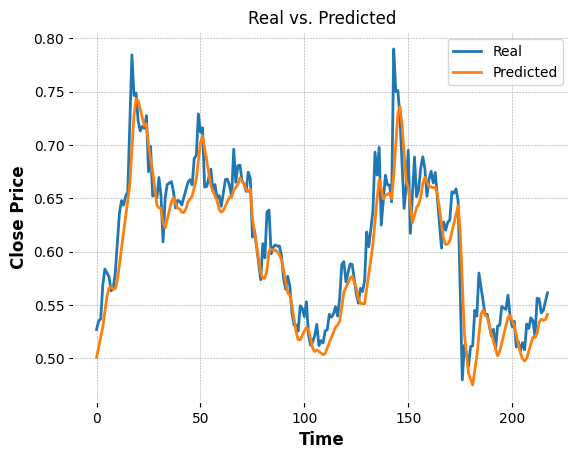

In [83]:
# prompt: plot pred and real

import matplotlib.pyplot as plt

# Assuming 'predictions' and 'y_test_5d' are defined from your previous code
# and contain the predicted and actual values, respectively.

# Assuming predictions and y_test_5d are numpy arrays
plt.plot(y_test_17d[:, 0], label='Real') # Plot the first column (Close Price)
plt.plot(predictions[:, 0], label='Predicted')  # Plot the first column (Close Price)
plt.xlabel('Time')
plt.ylabel('Close Price')
plt.title('Real vs. Predicted')
plt.legend()
plt.show()


In [84]:
# prompt: lstm with these data with tensorflow

import tensorflow as tf

# Define the LSTM model
model = tf.keras.Sequential([
    tf.keras.layers.LSTM(64, input_shape=(x_train_all.shape[1], x_train_all.shape[2])),
    tf.keras.layers.Dense(y_train_all.shape[1])
])

# Compile the model
model.compile(optimizer='adam', loss='mse')

# Train the model
model.fit(x_train_all, y_train_all, epochs=10, batch_size=32, validation_data=(x_valid_all, y_valid_all))

# Evaluate the model
loss = model.evaluate(x_test_all, y_test_all)
print('Test Loss:', loss)

# Make predictions
predictions = model.predict(x_test_all)
predictions


Epoch 1/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 0.1531 - val_loss: 0.0036
Epoch 2/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0067 - val_loss: 0.0022
Epoch 3/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0042 - val_loss: 0.0020
Epoch 4/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0041 - val_loss: 0.0020
Epoch 5/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0032 - val_loss: 0.0016
Epoch 6/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0025 - val_loss: 0.0015
Epoch 7/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0027 - val_loss: 0.0018
Epoch 8/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0025 - val_loss: 0.0015
Epoch 9/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0025 - val_loss: 0.0012
Epoch 10/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0020 - val_loss: 0.0014
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 9.5232e-04
Test Loss: 0.0009377668029628694
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


array([[0.5109254 , 0.51495796, 0.456247  , ..., 0.49738592, 0.49061793,
        0.47887832],
       [0.5206128 , 0.52419585, 0.46518546, ..., 0.50329435, 0.49256825,
        0.4883517 ],
       [0.5283588 , 0.5310487 , 0.4728591 , ..., 0.5090891 , 0.49578393,
        0.4948962 ],
       ...,
       [0.5477989 , 0.5505214 , 0.49538746, ..., 0.5357142 , 0.5200353 ,
        0.51125234],
       [0.54967785, 0.5519481 , 0.4972484 , ..., 0.5378323 , 0.52239704,
        0.51189804],
       [0.55425483, 0.5561789 , 0.50047415, ..., 0.54060674, 0.52548623,
        0.51623446]], dtype=float32)

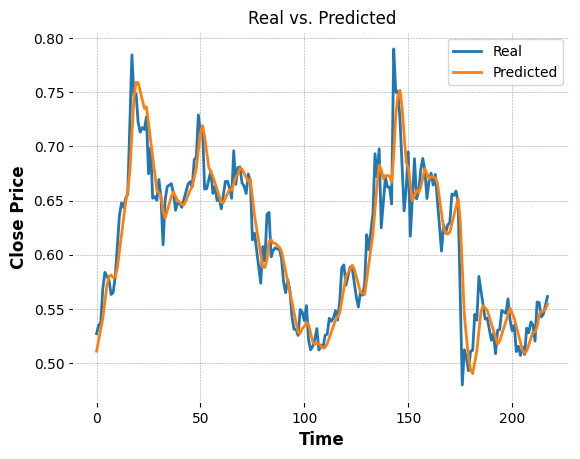

In [85]:
# prompt: plot pred and real

import matplotlib.pyplot as plt
# Assuming predictions and y_test_all are numpy arrays
plt.plot(y_test_all[:, 0], label='Real') # Plot the first column (Close Price)
plt.plot(predictions[:, 0], label='Predicted')  # Plot the first column (Close Price)
plt.xlabel('Time')
plt.ylabel('Close Price')
plt.title('Real vs. Predicted')
plt.legend()
plt.show()
